### Q1 : [Spatial Reasoning & Data Filtering] 
Spatial processing for Delhi-NCR region:   
We are given delhi_airshed.geojson and delhi_ncr_region.geojson files that need to be processed.  
Following are the steps :  
1. Loading the files and their coordinate reference system (EPSG) , standard : WGS84 - EPSG:4326
2. Converting this system to EPSG:32644 (metric CRS)
3. Plot a 60km x 60km grid using matplotlib
4. Filtering for images st. center coordinates lie in Delhi_airshed

Note:  During this task , to understand CRS system and learning geopandas lib for .geojson files , I took some help from web and chatgpt.  
References : https://geojson.org/geojson-spec.html#coordinate-reference-system-objects.


In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import os
from shapely.geometry import box, Point

In [9]:
# loading .geojson files using geopandas

ncr = gpd.read_file("../data/delhi_ncr_region.geojson")
airshed = gpd.read_file("../data/delhi_airshed.geojson")

print("NCR CRS:", ncr.crs)
print("Airshed CRS:", airshed.crs)
ncr.head()

NCR CRS: EPSG:4326
Airshed CRS: EPSG:4326


,geometry
0,"POLYGON ((76.85108 28.22115, 76.85219 28.22098..."
1,"POLYGON ((77.15903 29.29436, 77.15999 29.29427..."
2,"MULTIPOLYGON (((77.07565 27.27704, 77.07819 27..."
3,"POLYGON ((77.97073 28.71104, 77.97089 28.71096..."
4,"POLYGON ((77.2143 28.78524, 77.21521 28.78514,..."


Given .geojson files have degree based coordinate system - EPSG 4326 , we need to convert this to EPSG 32644 which is metric based to convert the data in 60km (ie. 60,000m in metric system) x 60km grid form.


In [10]:
ncr_grid = ncr.to_crs(epsg=32644)
airshed_grid = airshed.to_crs(epsg=32644)

print("Converted CRS:", ncr_grid.crs , airshed_grid.crs)

Converted CRS: EPSG:32644 EPSG:32644


In [11]:
# grid formation - bounding box 
xmin, ymin, xmax, ymax = ncr_grid.total_bounds

grid_size = 60000 # (metric system : 60k metres)
grid_cells = []

for x in np.arange(xmin, xmax, grid_size):
    for y in np.arange(ymin, ymax, grid_size):
        grid_cells.append(box(x, y, x + grid_size, y + grid_size))

grid = gpd.GeoDataFrame(grid_cells, columns=["geometry"], crs=ncr_grid.crs)
# clip the grid for ncr region
grid_clipped = gpd.overlay(grid, ncr_grid, how="intersection")

print("Number of grid cells:", len(grid_clipped))

Number of grid cells: 96


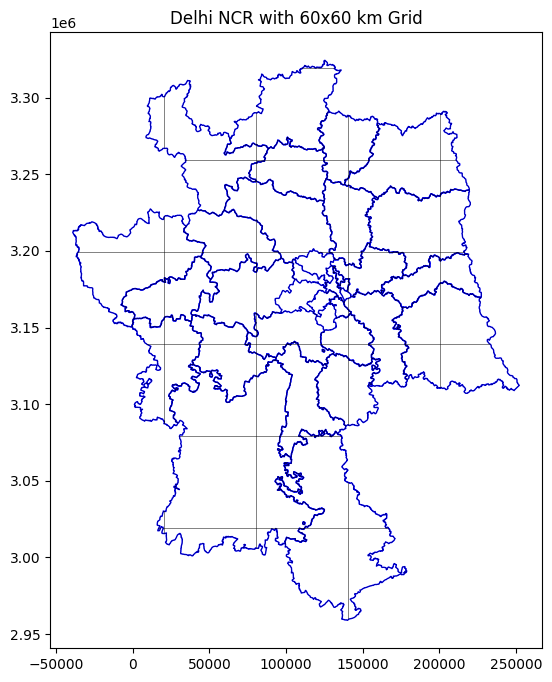

In [12]:
fig, ax = plt.subplots(figsize=(8, 8))

ncr_grid.boundary.plot(ax=ax, color="blue", linewidth=1)
grid_clipped.boundary.plot(ax=ax, color="black", linewidth=0.2)

plt.title("Delhi NCR with 60x60 km Grid")
plt.show()

Now, each file name in data/rgb folder is named in latitude_longitude.png format , we can use this to extract the points and then check if they lie in the airshed region.

In [13]:
image_folder = "../data/rgb"

all_images = [f for f in os.listdir(image_folder) if f.endswith(".png")]

print("Total images before filtering:", len(all_images))

points = []
valid_filenames = []

for fname in all_images:
    try:
        lat, lon = fname.replace(".png", "").split("_")
        lat, lon = float(lat), float(lon)

#shapely uses (x, y) = (lon, lat)
        points.append(Point(lon, lat))
        valid_filenames.append(fname)

    except:
        continue

points_gdf = gpd.GeoDataFrame({"filename": valid_filenames},
                              geometry=points,
                              crs="EPSG:4326")

Total images before filtering: 9216


In [14]:
gridpoints = points_gdf.to_crs(epsg=32644)
# retain only the pts in airshed 
points_inside = gpd.sjoin(gridpoints, ncr_grid, predicate="within")

print("Total images after filtering:", len(points_inside))

Total images after filtering: 8015


In [16]:
print("Total before:", len(gridpoints))
print("Total after:", len(points_inside))

# Check if any points fall outside
points_outside = gpd.sjoin(gridpoints, airshed_grid, predicate="within", how="left")


Total before: 9216
Total after: 8015


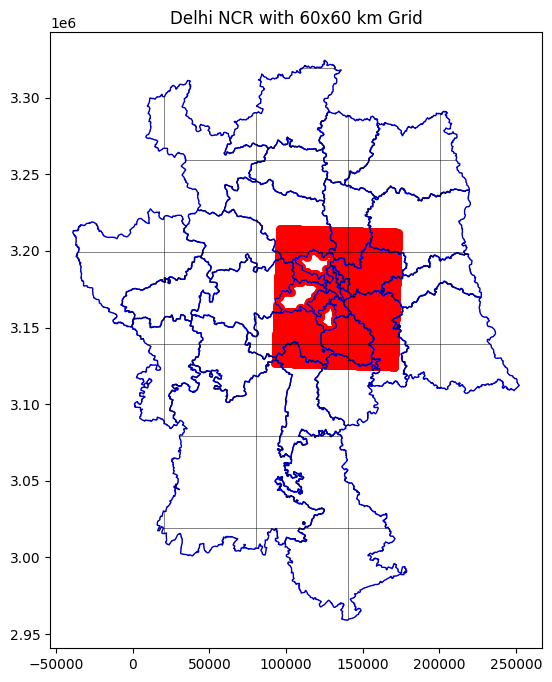

In [19]:
#filtered images plot
fig, ax = plt.subplots(figsize=(8, 8))

ncr_grid.boundary.plot(ax=ax, color="blue", linewidth=1)
grid_clipped.boundary.plot(ax=ax, color="black", linewidth=0.2)
points_inside.plot(ax=ax , color="red" , linewidth= 0.5)

plt.title("Delhi NCR with 60x60 km Grid")
plt.show()